<a href="https://colab.research.google.com/github/MalakMaher780/ML-Project/blob/main/GNN_for_Traffic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!unzip traffic.csv.zip

Archive:  traffic.csv.zip
  inflating: traffic.csv             


In [27]:
import pandas as pd
df = pd.read_csv('traffic.csv')

In [33]:
import numpy as np

# A '1' means a connection exists; the diagonal is all '1' for self-loops.
# Rows/Cols 0, 1, 2, 3 correspond to Junctions 1, 2, 3, 4.
tilde_A = np.array([
    [1, 1, 0, 0], # Junction 1: Connected to self and Junction 2
    [1, 1, 1, 1], # Junction 2: Connected to self, J1, J3, and J4 (The Hub) [cite: 49]
    [0, 1, 1, 1], # Junction 3: Connected to self, J2, and J4
    [0, 1, 1, 1]  # Junction 4: Connected to self, J2, and J3
])
print("--- Graph Structure (Adjacency Matrix with Self-Loops) ---")
print(tilde_A)
print("\n")

--- Graph Structure (Adjacency Matrix with Self-Loops) ---
[[1 1 0 0]
 [1 1 1 1]
 [0 1 1 1]
 [0 1 1 1]]




In [29]:
# Values taken from your traffic.csv for the 2017-01-01 timestamp
X_features = np.array([
    [27], # Vehicles at Junction 1
    [7],  # Vehicles at Junction 2
    [10], # Vehicles at Junction 3
    [3]   # Vehicles at Junction 4
])

In [37]:
# --- PART 4: THE GNN OPERATION ---
learned_weight = 0.2

print("--- Step 1: Matrix Multiplication (tilde_A * X_features) ---")
print("(This naturally aggregates knowledge from neighbors!)")
# This is the 'Aggregation' step from the PDF
aggregated_values = np.matmul(tilde_A, X_features)
print(aggregated_values)
print("\n")

print("--- Step 2: Linear Transformation (Aggregation * Weight) ---")
print(f"(Applying the learned weight W = {learned_weight})")
# This is the 'Transformation' step from the PDF
final_output = aggregated_values * learned_weight
print(final_output)
print("\n")

--- Step 1: Matrix Multiplication (tilde_A * X_features) ---
(This naturally aggregates knowledge from neighbors!)
[[34]
 [47]
 [20]
 [20]]


--- Step 2: Linear Transformation (Aggregation * Weight) ---
(Applying the learned weight W = 0.2)
[[6.8]
 [9.4]
 [4. ]
 [4. ]]




In [36]:
# --- PART 5: FINAL COMPARISON ---
print("--- Final Comparison (Latent State vs. Original Knowledge) ---")
junctions = ["Junction 1", "Junction 2", "Junction 3", "Junction 4"]

for i, junction in enumerate(junctions):
    orig = X_features[i][0]
    latent = final_output[i][0]
    # format output with 1 decimal place as shown in the doctor's results
    print(f"{junction}: Original Vehicles = {orig:.1f} | GNN Latent State = {latent:.1f}")

--- Final Comparison (Latent State vs. Original Knowledge) ---
Junction 1: Original Vehicles = 27.0 | GNN Latent State = 6.8
Junction 2: Original Vehicles = 7.0 | GNN Latent State = 9.4
Junction 3: Original Vehicles = 10.0 | GNN Latent State = 4.0
Junction 4: Original Vehicles = 3.0 | GNN Latent State = 4.0


/tmp/ipykernel_9928/251699287.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  G.add_node(name, orig=float(X_features[i]), latent=float(latent_states[i]))


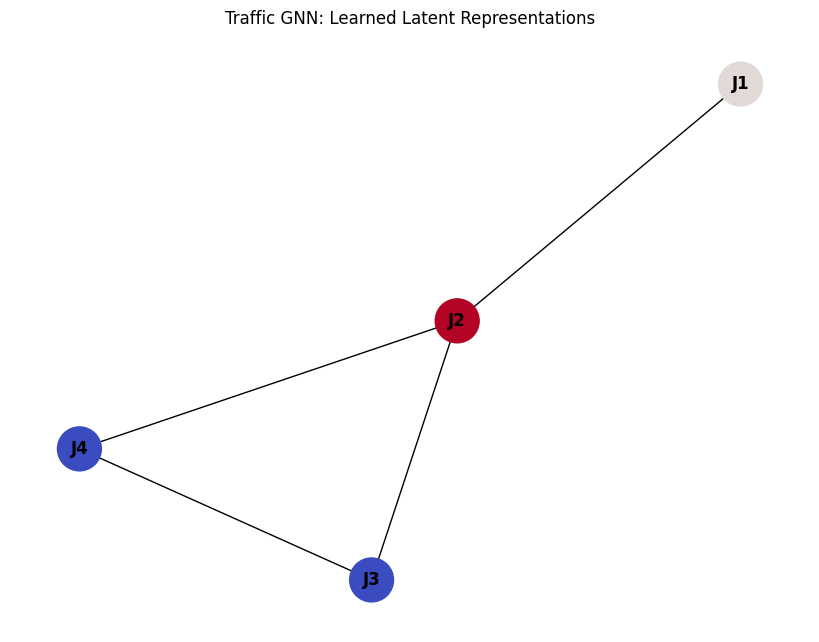

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
# Add nodes with both original features and the new latent states [cite: 181]
junctions = ["J1", "J2", "J3", "J4"]
for i, name in enumerate(junctions):
    G.add_node(name, orig=float(X_features[i]), latent=float(latent_states[i]))

# Define connections [cite: 188]
G.add_edges_from([("J1", "J2"), ("J2", "J3"), ("J3", "J4"), ("J4", "J2")])

# Use color to represent the "Latent State" (Risk) [cite: 206, 207]
node_colors = [G.nodes[n]['latent'] for n in G.nodes]
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.coolwarm,
        node_size=1000, font_weight='bold')
plt.title("Traffic GNN: Learned Latent Representations")
plt.show()